In [ ]:
import pandas as pd
from groq import Groq
import os
import matplotlib.pyplot as plt
import plotly.express as px

with open('groq.txt') as file:
    api_key = str(file.readline())

os.environ['GROQ_API_KEY'] = api_key

# Load the fintech dataset
df = pd.read_csv("fintechdf_categorized.csv", encoding="latin-1")

# Get dataset info for context
columns_info = df.dtypes.to_string()
sample_data = df.head(3).to_string()
shape_info = f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns"

# Create context about the dataset for visualization
visual_context = f"""
You are a data visualization expert. You have access to a fintech startup dataset loaded in a pandas DataFrame called 'df'.

{shape_info}

Columns and their types:
{columns_info}


The dataset contains information about European fintech startups including:
- Basic info: ID, Name, Long description, HQ city, Launch year, Founders
- Funding: Total funding (EUR M), Last round
- Category flags (binary 0/1): digital_payments_processing, insurance_insurtech_underwriting, 
  blockchain_cryptocurrency_assets, lending_credit_financing, investment_wealth_trading,
  corporate_treasury_accounting, sustainability_carbon_climate, tax_legal_planning, mergers_acquisitions_advisory

"""

# User request - change this to request different visualizations
user_prompt = "Create a pie chart showing the distribution of startups across the different fintech categories"

In [11]:
# Initialize Groq client
client = Groq()

# Get the LLM to generate visualization code
response = client.chat.completions.create(
    model="groq/compound-mini",
    messages=[
        {
            "role": "system",
            "content": visual_context
        },
        {
            "role": "user",
            "content": user_prompt
        }
    ],
    temperature=1,
    max_completion_tokens=8192,
    top_p=1,
    stream=False,
    stop=None,
    compound_custom={"tools":{"enabled_tools":["code_interpreter"]}}
)

# Final output
generated_code = response.choices[0].message.content
print(response.choices[0].message.content)

Below is a short, self‑contained Python snippet that

1. **Identifies the fintech‑category columns** (the nine `int64` columns that indicate whether a startup is active in a given area).  
2. **Counts how many startups belong to each category** (by summing the 0/1 values).  
3. **Draws a pie chart** with Matplotlib, adding percentages and a legend for readability.

```python
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1️⃣  Load / reference your DataFrame
# -------------------------------------------------
# Assuming the DataFrame is already in memory as `df`
# If you need to read it from a CSV you could do:
# df = pd.read_csv('your_file.csv')

# -------------------------------------------------
# 2️⃣  Define the fintech‑category columns
# -------------------------------------------------
category_cols = [
    "digital_payments_processing",
    "insurance_insurtech_underwriting",
    "blockchain_cryptocurrency_assets",
    "

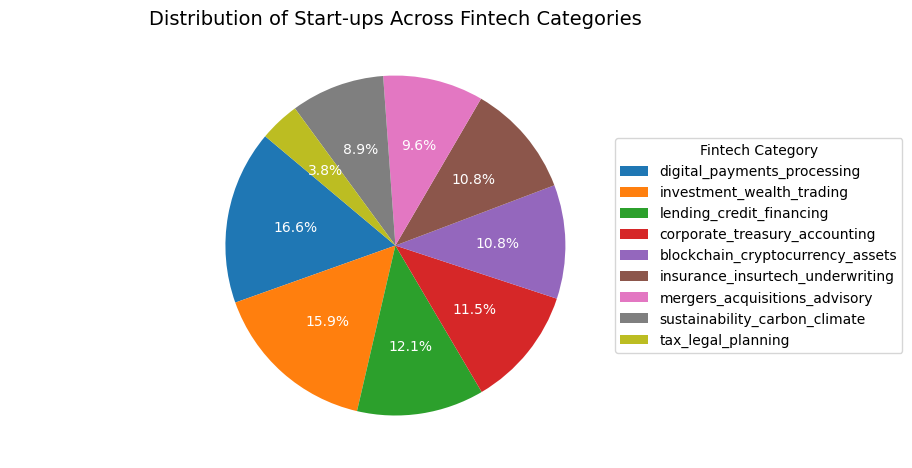

In [12]:


# Clean the generated code (remove markdown code blocks if present)
code_to_run = generated_code
if "```python" in code_to_run:
    code_to_run = code_to_run.split("```python")[1].split("```")[0]
elif "```" in code_to_run:
    code_to_run = code_to_run.split("```")[1].split("```")[0]

# Execute the code
exec(code_to_run)